 GRUPITÖÖ

INSTALLIMINE, ANDMETEGA HÄÄLESTAMINE/LUGEMINE

In [246]:
%pip install jinja2

Note: you may need to restart the kernel to use updated packages.


In [247]:
import pandas as pd
import duckdb as dd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [248]:
bolt_andmed = pd.read_csv("takso_andmed_clean.csv")


In [249]:
bolt_harjutus = bolt_andmed.copy()

## PÕHIANDMESTIKU TULPADE NIMISTIK

In [250]:
for col in bolt_andmed.columns:
    print(f"{col},")

order_id_new,
order_try_id_new,
calc_created,
metered_price,
upfront_price,
distance,
duration,
gps_confidence,
entered_by,
b_state,
dest_change_number,
prediction_price_type,
predicted_distance,
predicted_duration,
change_reason_pricing,
ticket_id_new,
rider_app_version,
order_state,
order_try_state,
driver_app_version,
driver_device_uid_new,
device_name,
eu_indicator,
overpaid_ride_ticket,
fraud_score,
date,
time,
day_of_week,
day_of_week_nr,
month,
year,
is_invalid_ride,
fraud_score_status,


In [251]:
df_model = train_model.copy()

# JUHENDAJA poolsed küsimused kohtumistelt

## Kas ticket_id_new'l on mõni tugev/kasulik tunnus ja seotuvus order_id_new'ga?


In [252]:
pd.crosstab(
    df_model["ticket_id_new"].notna(),
    df_model["overpaid_ride_ticket"],
    normalize="index"
) * 100

overpaid_ride_ticket,0,1
ticket_id_new,,
True,97.180135,2.819865


* Võrdluses ülemakstud sõitude piletitega näitab risttabel, et puudub seos ja info, mis võiks oll kasulik põhiküsimuse vastamiseks

## Overcharge statuse ja overpaid ride piletite võrdlus

In [253]:
pd.crosstab(
    bolt_andmed["overcharge_status"],
    bolt_andmed["overpaid_ride_ticket"],
    normalize="index"
) * 100

KeyError: 'overcharge_status'

## MÕÕDIKUD

In [258]:
bolt_andmed["duration_difference"] = (
    bolt_andmed["duration"] - bolt_andmed["predicted_duration"]
)

In [259]:
bolt_andmed["distance_difference"] = (
    bolt_andmed["distance"] - bolt_andmed["predicted_distance"]
)

In [260]:
np.random.seed(42)

n_samples = len(bolt_andmed)
n_test = int(0.3 * n_samples)
split_flags = np.zeros(n_samples, dtype=int)
test_indices = np.random.choice(n_samples, size=n_test, replace=False)
split_flags[test_indices] = 1

bolt_andmed["test_train"] = split_flags


# LINEAARREGRESSIOON

## TRAIN ja TEST data sidumine põhiandmestikuga + vääringute seadmine

In [261]:
train_data = bolt_andmed[bolt_andmed["test_train"] == 0]

test_data = bolt_andmed[bolt_andmed["test_train"] == 1]

* LinearRegression install

In [262]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()



## TRAIN ETTEVALMISTUS : grupeerimine, aja tähenduse muutmine calc_created tulbas

In [263]:
features = [
    "distance",
    "predicted_distance",
    "predicted_duration",
    "gps_confidence",
    "upfront_price",
    "year",
    "month",
    "hour",
    "weekday",
    "metered_price",
    "dest_change_number",
    "eu_indicator",
    "ticket_id_new"
]

train_data["year"] = pd.to_datetime(train_data["calc_created"]).dt.year
train_data["month"] = pd.to_datetime(train_data["calc_created"]).dt.month
train_data["hour"] = pd.to_datetime(train_data["calc_created"]).dt.hour
train_data["weekday"] = pd.to_datetime(train_data["calc_created"]).dt.weekday
train_model = train_data.dropna(subset=features + ["duration"])



## TEST DATA ETTEVALMISTUS

In [264]:
test_data["calc_created"] = pd.to_datetime(test_data["calc_created"])

test_data["year"] = test_data["calc_created"].dt.year
test_data["month"] = test_data["calc_created"].dt.month
test_data["hour"] = test_data["calc_created"].dt.hour
test_data["weekday"] = test_data["calc_created"].dt.weekday

## Train ja Test andmete NaNidest puhastamine

In [265]:
train_model = train_data.dropna(subset=features + ["duration"])
test_model = test_data.dropna(subset=features)


## MUDELI TREENIMINE/FITTIMINE

In [266]:

model.fit(
    train_model[features],
    train_model["duration"]
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 0.07, -0.08, 1.18,..., 166.48,-313.84, 0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['distance','predicted_distance','predicted_duration',..., 'dest_change_number','eu_indicator','ticket_id_new']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,161
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


## Test mudeli R2 skoor

In [269]:
r2_score(
    test_model["duration"],
    duration_result
)

0.5944534324110684

## Scatterplot x= distance, y= duration

<Axes: xlabel='distance', ylabel='duration'>

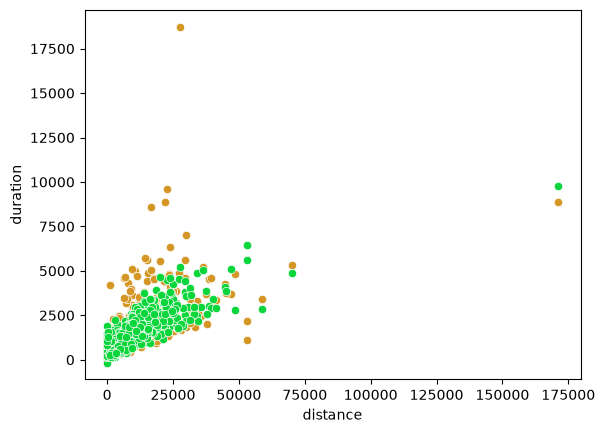

In [270]:
sns.scatterplot(test_model, x="distance", y="duration", color="#D49725")
sns.scatterplot(x=test_model["distance"], y=duration_result, color="#0AD53A")

* Test mudeli: upfront_price, metered_price, predicted_distance ja predicted_duration korrelatsiooni tabel

In [271]:
test_model[
    ["upfront_price", "metered_price", "predicted_distance", "predicted_duration"]
].corr()

,upfront_price,metered_price,predicted_distance,predicted_duration
upfront_price,1.000000,0.393613,0.693056,0.755825
metered_price,0.393613,1.000000,0.161267,0.372521
predicted_distance,0.693056,0.161267,1.000000,0.905041
predicted_duration,0.755825,0.372521,0.905041,1.000000


(0.0, 10000.0)

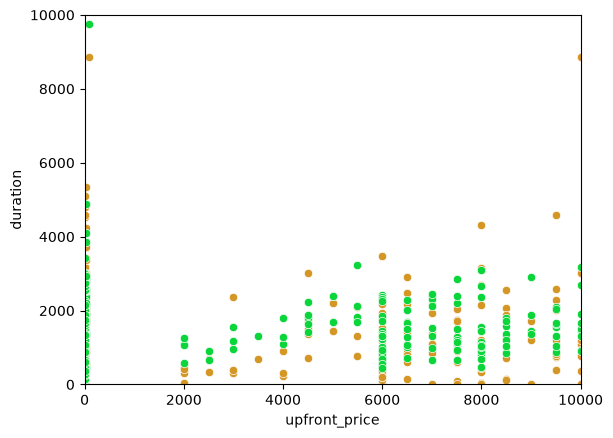

In [272]:
sns.scatterplot(test_model, x="upfront_price", y="duration", color="#D49725")
sns.scatterplot(
    x=test_model["upfront_price"],
    y=duration_result,
    color="#0AD53A"
)

plt.xlim(0, 10000)
plt.ylim(0, 10000)

# Overpaid_ride piletid

In [273]:
bolt_andmed["overpaid_ride_ticket"].value_counts()

overpaid_ride_ticket
0    4606
1     337
Name: count, dtype: int64

## Ennustatava sõiduaja vs päris sõiduaja võrdlus overpaid_ride piletitega

(0.0, 10000.0)

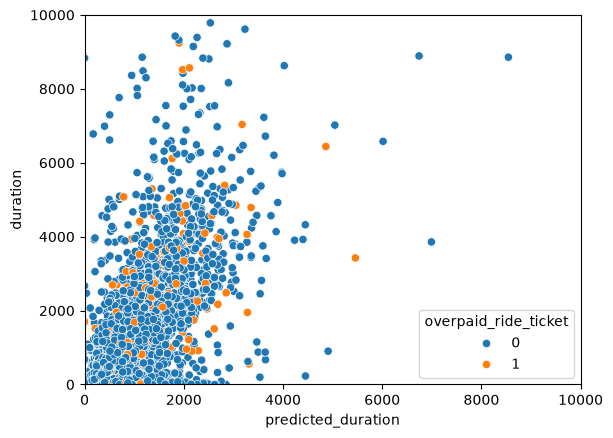

In [274]:
sns.scatterplot(
    data=bolt_andmed, 
    x="predicted_duration", 
    y="duration",
    hue= "overpaid_ride_ticket"
)

plt.xlim(0, 10000)
plt.ylim(0, 10000)

## GPS signaal

#  vs Overpaid_Ride piletid - HEATMAP võrdlus

<Axes: xlabel='overpaid_ride_ticket', ylabel='gps_confidence'>

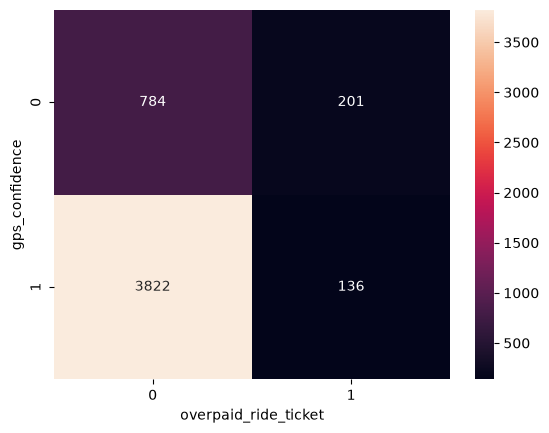

In [275]:
sns.heatmap(
    pd.crosstab(
        bolt_andmed["gps_confidence"],
        bolt_andmed["overpaid_ride_ticket"]
    ),
    annot=True,
    fmt="d"
)



# vs Overpaid_ride piletite suhe

In [276]:
gps_analysis = (
    bolt_andmed
    .groupby("gps_confidence")
    .agg(
        sõite=("overpaid_ride_ticket", "count"),
        overcharge_ticketid=("overpaid_ride_ticket", "sum"),
        overcharge_rate=("overpaid_ride_ticket", "mean")
    )
)

gps_analysis["overcharge_rate"] = gps_analysis["overcharge_rate"] * 100

gps_analysis

,sõite,overcharge_ticketid,overcharge_rate
gps_confidence,,,
0,985,201,20.406091
1,3958,136,3.436079


# vs Overcharge piletite suhe ennustatud tüübiga 

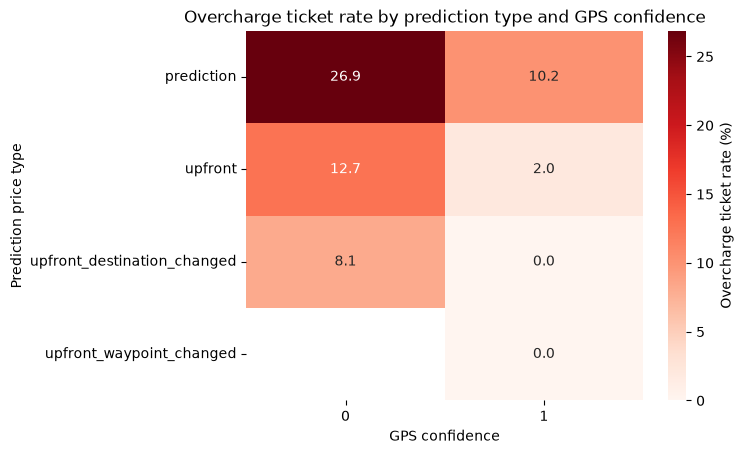

In [277]:
heatmap_data = pd.crosstab(
    bolt_andmed["prediction_price_type"],
    bolt_andmed["gps_confidence"],
    values=bolt_andmed["overpaid_ride_ticket"],
    aggfunc="mean"
) * 100

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    cbar_kws={"label": "Overcharge ticket rate (%)"}
)

plt.title("Overcharge ticket rate by prediction type and GPS confidence")
plt.xlabel("GPS confidence")
plt.ylabel("Prediction price type")
plt.show()

## Hinnastamise tüübi analüüs 

In [278]:
price_type_analysis = (
    bolt_andmed
    .groupby("prediction_price_type")
    .agg(
        sõite=("overpaid_ride_ticket", "count"),
        overcharge_ticketid=("overpaid_ride_ticket", "sum"),
        overcharge_rate=("overpaid_ride_ticket", "mean")
    )
)

price_type_analysis["overcharge_rate"] *= 100

price_type_analysis

,sõite,overcharge_ticketid,overcharge_rate
prediction_price_type,,,
prediction,1279,222,17.357310
upfront,3432,112,3.263403
upfront_destination_changed,208,3,1.442308
upfront_waypoint_changed,4,0,0.000000


## Ennustatud vs actual distance

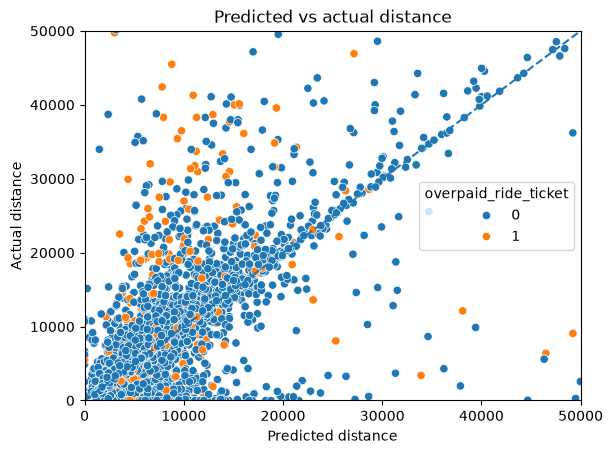

In [279]:
sns.scatterplot(
    data=bolt_andmed,
    x="predicted_distance",
    y="distance",
    hue="overpaid_ride_ticket"
)
plt.xlim(0, 50000)
plt.ylim(0, 50000)
plt.xlabel("Predicted distance")
plt.ylabel("Actual distance")
plt.title("Predicted vs actual distance")
plt.plot([0, 50000], [0, 50000], linestyle="--")
plt.show()


# Ülehinnatud sõitude staatus tulba loomine / analüüs 

In [280]:
import numpy as np

## Staatuste kategoriseerimine

In [281]:
bolt_andmed["overcharge_status"] = np.where(
    bolt_andmed["upfront_price"].isna(),
    "UNKNOWN",
    np.where(
        bolt_andmed["metered_price"]> bolt_andmed["upfront_price"],
        "OVERCHARGE",
        "NO OVERCHARGE"
    )
)

## Kontroll

In [282]:
bolt_andmed["overcharge_status"].value_counts()

overcharge_status
OVERCHARGE       1991
UNKNOWN          1534
NO OVERCHARGE    1418
Name: count, dtype: int64

# Ülehinnastatud sõitude võrdlus VS fraud skoor

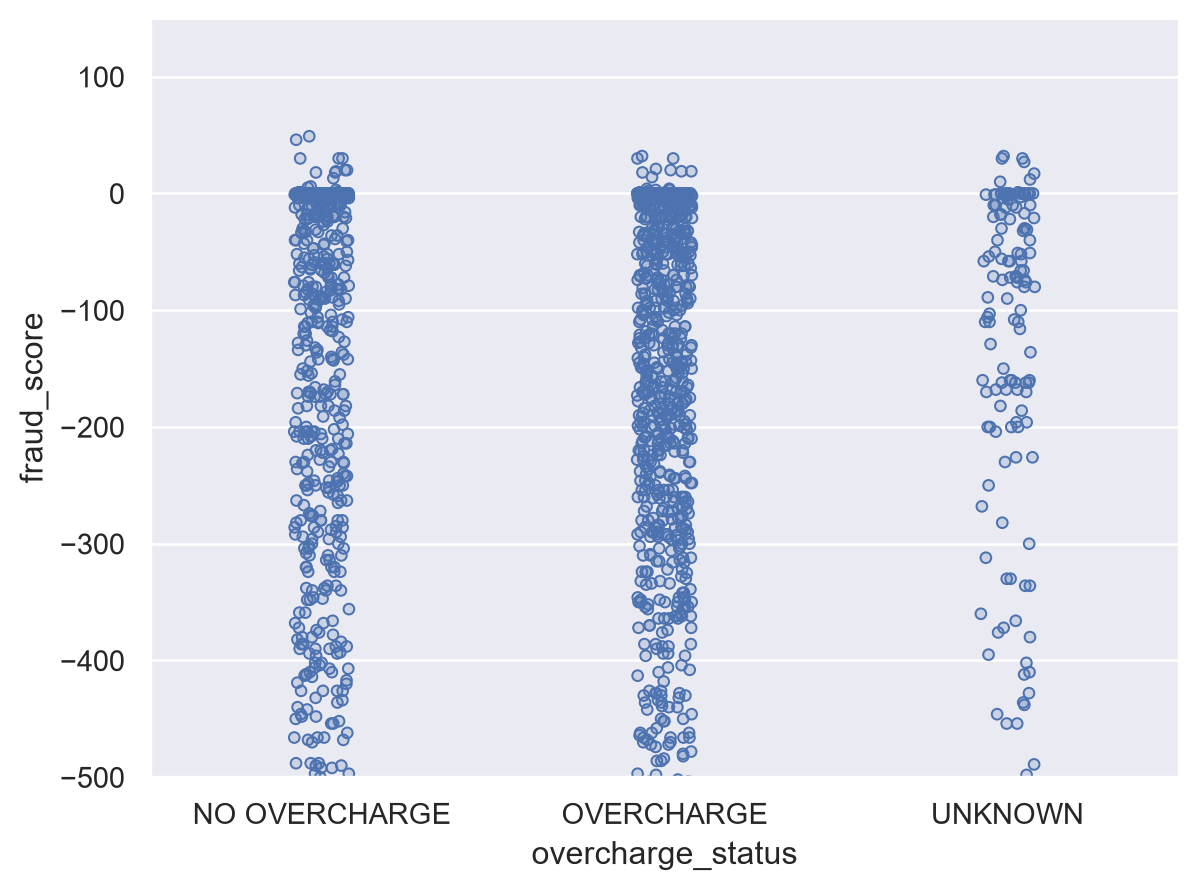

In [283]:
import seaborn.objects as so

(
    so.Plot(bolt_andmed, "overcharge_status", "fraud_score")
    .add(so.Dots(), so.Jitter())
    .limit(y=(-500, 150))
)

## Sõidu tegeliku kestvuse erinevus ettevõtte oma ennustamise mudeliga (pos. tegelik > ennustatud, neg. tegelik < ennustatud,  0 tegelik = ennustatud) - päeva perioodi lõikes

In [284]:
bolt_test = bolt_andmed.copy()

In [285]:
bolt_test["calc_created"] = pd.to_datetime(bolt_test["calc_created"])

bolt_test["päeva_periood"] = pd.cut(
    bolt_test["calc_created"].dt.hour,
    bins=[-1, 6, 12, 18, 24],
    labels=["öö", "hommik", "lõuna", "õhtu"]
)

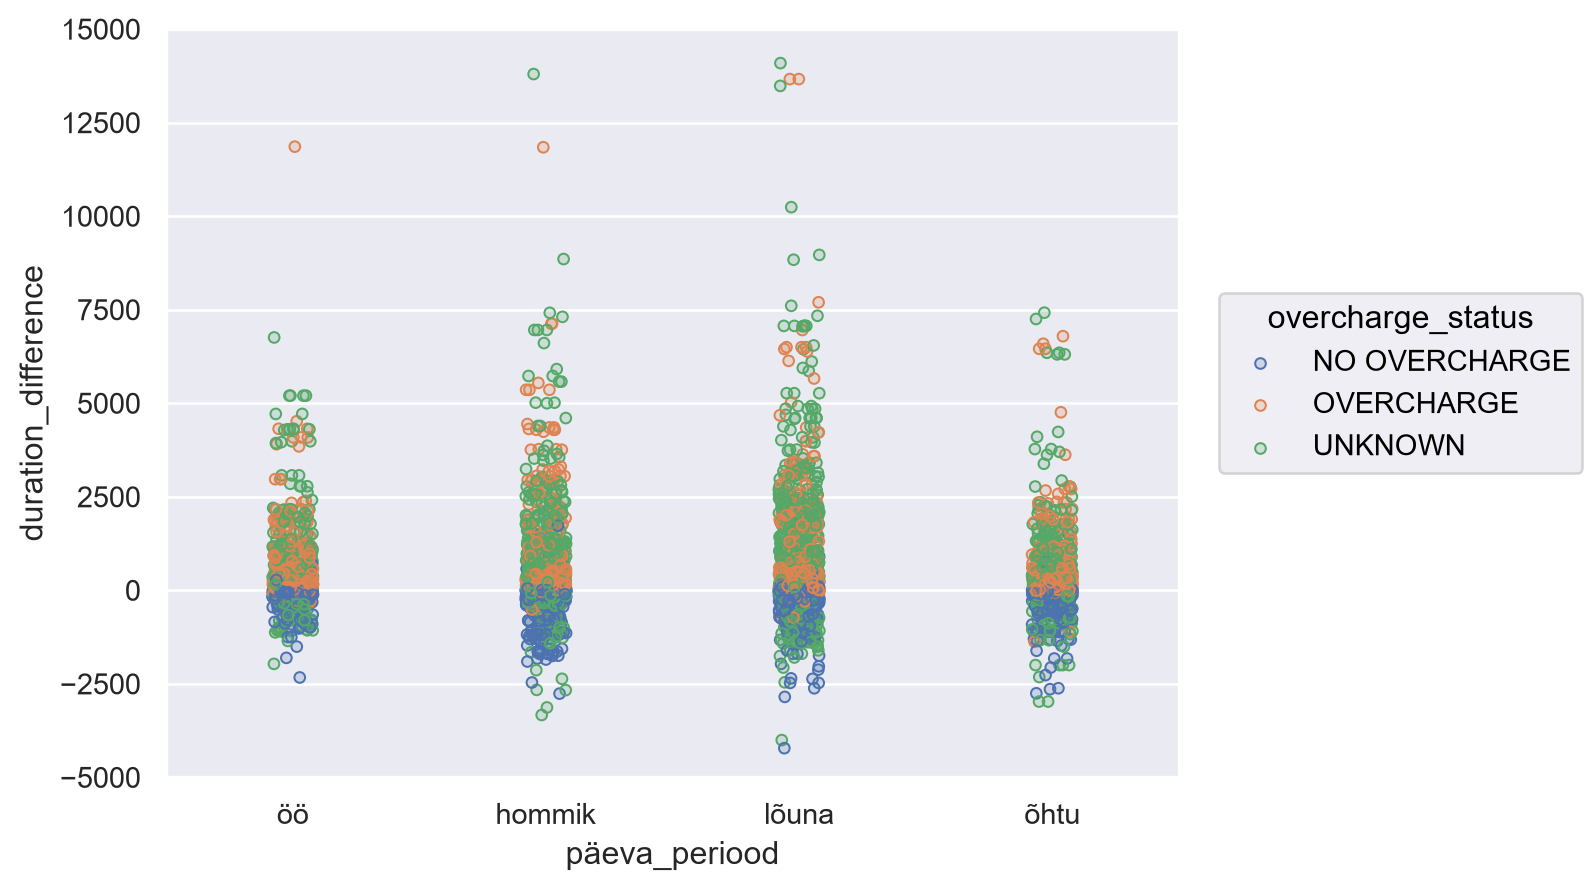

In [286]:
(
    so.Plot(
        bolt_test,
        x="päeva_periood",
         y="duration_difference",
        color="overcharge_status"
    )
    .add(so.Dots(), so.Jitter())
    .limit(y=(-5000, 15000))
)

## Sõidu tegelik pikkus vs ennustatav distants (pos. tegelik > ennustatud, neg. tegelik < ennustatud, 0 tegelik = ennustatud) - päeva perioodi lõikes

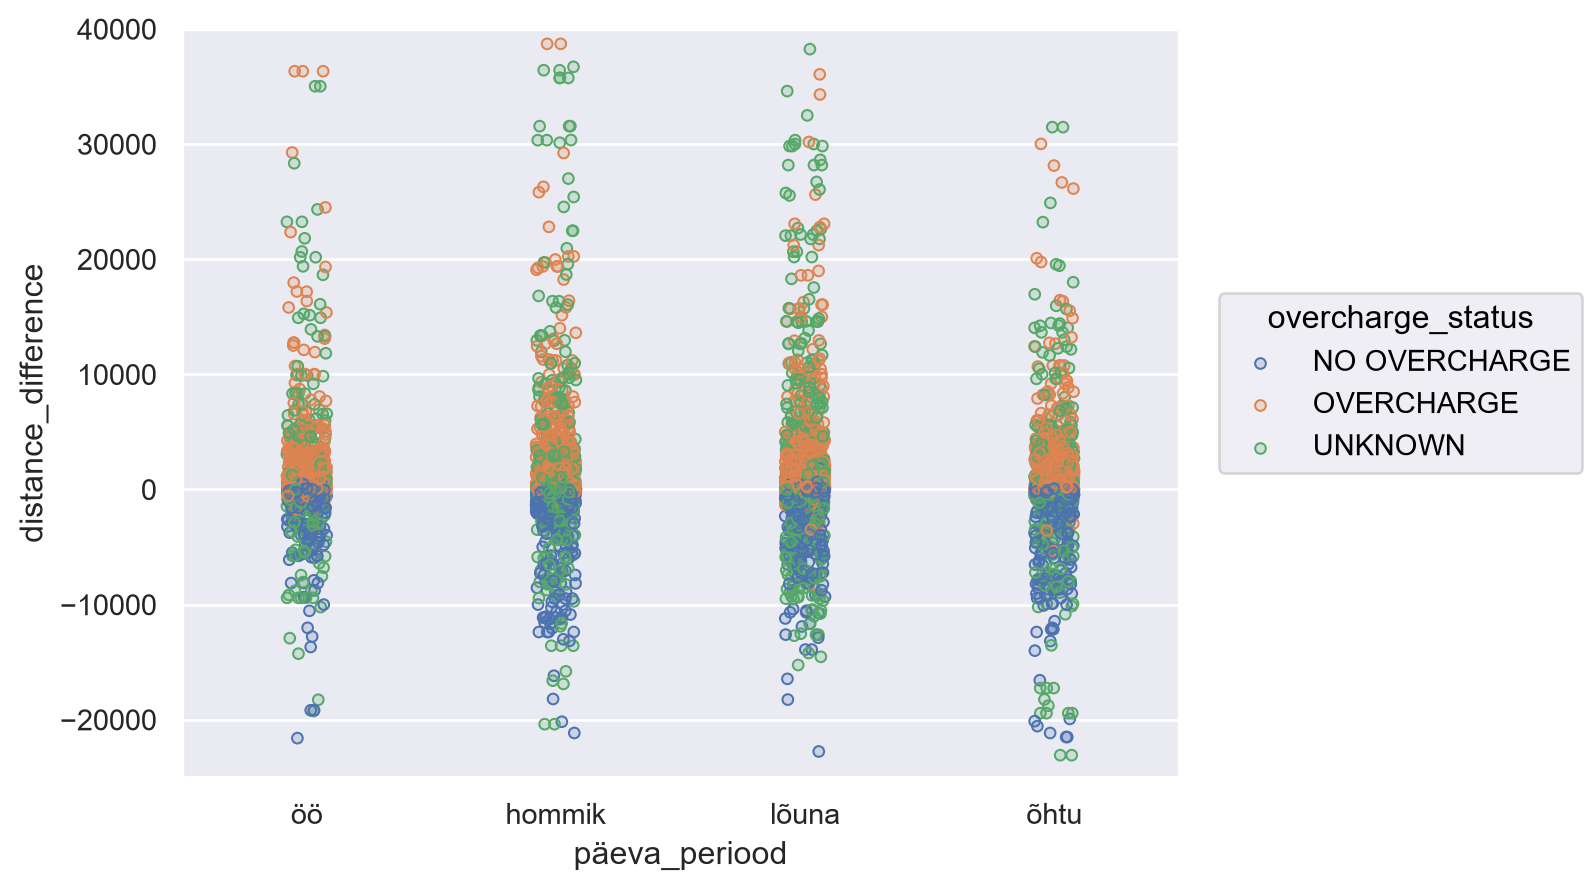

In [287]:
(
    so.Plot(
        bolt_test,
        x="päeva_periood",
         y="distance_difference",
        color="overcharge_status"
    )
    .add(so.Dots(), so.Jitter())
    .limit(y=(-25000, 40000))
)

## Minupoolne järeldus: 

Tulemused viitavad, et üheks võimalikuks strateegiaks overcharge-juhtumite vähendamisel võiks olla prognoosimudeli järjepidev edasiarendamine. Mudelit saab uute sõitude ja juhtumite põhjal korduvalt treenida, valideerida ning vajadusel täiendada uute tunnuste või andmetega. Selline iteratiivne lähenemine võimaldaks mudelil ajas kohaneda ning parandada prognooside täpsust, kui koguneb rohkem informatsiooni tegelike sõitude ja nende erinevuste kohta prognoositust.

## Sõitude staatuse järgi ristvõrdlus EU, GPS (index) näitel

In [288]:
pd.crosstab(
    bolt_andmed["overcharge_status"],
    [bolt_andmed["eu_indicator"], bolt_andmed["gps_confidence"]],
    normalize="index"
) * 100

eu_indicator               0                    1           
gps_confidence             0          1         0          1
overcharge_status                                           
NO OVERCHARGE       6.488011  19.393512  1.833568  72.284908
OVERCHARGE         10.296334  15.570065  2.461075  71.672526
UNKNOWN            36.571056  47.588005  3.389831  12.451108

# HÜPOTEES I
"Kui väljaspool EU parandada GPS-i usaldusväärsust, võib see vähendada "unknown" juhtumite osakaalu ja potensiaalselt muuta hinnastamise täpsust.

EU = 0

GPS confidence 0: 39.5%

GPS confidence 1: 60.5%

UNKNOWN: 59.4%

EU = 1

GPS confidence 0: 4.6%

GPS confidence 1: 95.4%

UNKNOWN: 8.8%

## JÄRELDUS, KOGU ANDMESTIKU ALUSEL "overcharge staatuse" kategoriseerimisel hinnastamise loogika alusel (upfront_price < metered_price) EI saa võtta aluseks KOGU andmestikku, kuna 1534 SÕITU / kogu summast 4943 on UNKNOWN (puudub hinnastamiseinfo ning otsides loogikat mujalt KOGU andmestikust ei õnnestunud leida sobilik loogika) mistõttu ei ole andmed sobilikud lõppjärelduse tegemiseks - OTSUS: Keskenduda vaid Overcharge ja No Overcharge juhtumite/sõitudele.

## UUS ANDMESTIK , kus on välja filtreeritud "UNKNOWN" sõidud

In [289]:
bolt_andmed_uuendatud = bolt_andmed[
    bolt_andmed["upfront_price"].notna()
].copy()

In [290]:
bolt_andmed_uuendatud.shape

(3409, 37)

## Analüüs hõlmab 3409 sõitu, mille puhul olid olemas mõlemad overcharge-staatuse määramiseks vajalikud hinnaväljad. 1534 sõitu jäeti analüüsist välja, kuna upfront_price puudus ning nende puhul ei olnud võimalik rakendada kasutatud overcharge'i definitsiooni.

## OVERCHARGE / NO OVERCHARGE sõitudel puudub seos EU indikaatorist

In [310]:
bolt_andmed_uuendatud.groupby("eu_indicator")["overcharge_status"].value_counts(normalize=True)

eu_indicator  overcharge_status
0             OVERCHARGE           0.583900
              NO OVERCHARGE        0.416100
1             OVERCHARGE           0.584092
              NO OVERCHARGE        0.415908
Name: proportion, dtype: float64

## MINIMAALNE SEOS OVERCHARGE / NO OVERCHARGE sõitudel GPS signaaliga

In [292]:
bolt_andmed_uuendatud.groupby("gps_confidence")["overcharge_status"].value_counts(normalize=True)

gps_confidence  overcharge_status
0               OVERCHARGE           0.682796
                NO OVERCHARGE        0.317204
1               OVERCHARGE           0.571946
                NO OVERCHARGE        0.428054
Name: proportion, dtype: float64

* OVERCHARGE ja NO OVERCHARGE keskmise arvutamine Uprfront_price ja metered_price võrdluses

In [293]:
bolt_andmed_uuendatud.groupby("overcharge_status")[
    ["upfront_price", "metered_price"]
].mean()

,upfront_price,metered_price
overcharge_status,,
NO OVERCHARGE,4719.528773,2495.741495
OVERCHARGE,3761.664792,6782.346876


* OVERCHARGE ja NO OVERCHARGE KORRELATSIOON LOGARITMIGA

In [294]:
bolt_andmed_uuendatud[
    ["upfront_price", "metered_price"]
].corr()

,upfront_price,metered_price
upfront_price,1.000000,0.420772
metered_price,0.420772,1.000000


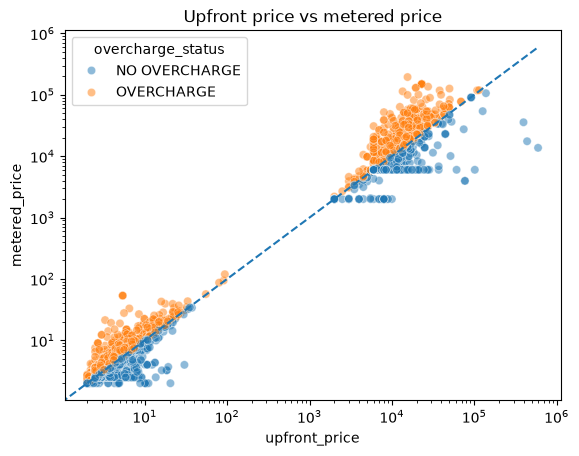

In [295]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=bolt_andmed_uuendatud,
    x="upfront_price",
    y="metered_price",
    hue="overcharge_status",
    alpha=0.5
)

plt.plot(
    [0, bolt_andmed_uuendatud["upfront_price"].max()],
    [0, bolt_andmed_uuendatud["upfront_price"].max()],
    linestyle="--"
)

plt.xscale("log")
plt.yscale("log")
plt.title("Upfront price vs metered price")
plt.show()

* HOUR tulba liitmine bolt-andmetega

In [296]:
bolt_harjutus["calc_created"] = pd.to_datetime(
    bolt_harjutus["calc_created"]
)

bolt_harjutus["hour"] = bolt_harjutus["calc_created"].dt.hour

## KAHE TEKSTILISE (String) väärtusega tulpade numbriliseks vääringuks teisendamine

In [297]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=100
)

In [298]:
bolt_harjutus[["driver_app_version", "device_name"]].nunique()

driver_app_version     33
device_name           497
dtype: int64

## Seadmete tükeldamine +  filtreerimine kategooriate järgi

In [299]:
bolt_harjutus["device_brand"] = np.select(
    [
        bolt_harjutus["device_name"].str.contains("TECNO", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("SAMSUNG", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("HUAWEI", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("IPHONE", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("NOKIA|HMD Global", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("ITEL", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("XIAOMI", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("INFINIX", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("LGE|LG", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("FOXCONN", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("ALPS", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("OPPO", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("SONY", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("LAVA", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("ZTE", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("BullittGroup", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("DIGMA", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("LENOVO", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("ASUS", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("SHARP", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("TCL", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("FUJITSU", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("MOTOROLA", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("BLACKVIEW", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("GOOGLE|PIXEL", case=False, na=False)
    ],
    [
        "TECNO", "Samsung", "Huawei", "Apple", "Nokia", "Itel",
        "Xiaomi", "Infinix", "LG", "Foxconn", "Alps", "OPPO",
        "Sony", "LAVA", "ZTE", "BullittGroup", "DIGMA", "Lenovo",
        "Asus", "Sharp", "TCL", "Fujitsu", "Motorola", "Blackview",
        "Google"
    ],
    default="Other"
)

In [300]:
bolt_harjutus["device_brand"].value_counts()

device_brand
Samsung         1683
TECNO            933
Huawei           724
Apple            426
Infinix          266
Xiaomi           261
Nokia            201
Itel             120
Other             67
Sony              46
LG                39
Lenovo            23
Foxconn           23
OPPO              22
BullittGroup      22
Alps              11
Blackview         11
LAVA              10
ZTE               10
Asus               9
DIGMA              7
Sharp              7
TCL                7
Fujitsu            7
Motorola           4
Google             4
Name: count, dtype: int64

## Overcharge staatusele vääringu 0 ja 1 lisamine

In [301]:
y = (bolt_andmed_uuendatud["overcharge_status"] == "OVERCHARGE").astype(int)

* SUPPORT - mitu tegelikku juhtu meil oli? 919 norm sõitu, 70 overcharge sõitu

* RECALL - kui palju tegelikest juhtudest üles leidsime?
Overcharge 70 x 0.63 = 44 sõitu (ehk need päris sõidud, mis olid ka piisava infoga nendest 44 leidis ka treenitud mudel ülesse) = 26 jäi leidmata!

* PRECISION - kui sageli on mudeli leitud juhtum päriselt õige? Kõigist sõitudest, mille sa kuulutasid Overchargeiks, kui palju tegelikult olid overchargid? 0.16 = 16% ehk 70 sõitu on 100%

* F1 SKOOR püüab need kaks üheks numbriks kokku võtta (precision (0.16) + recall (0.63) = F1 Skoor 0.25

* ACCURACY - 0.73 ehk kõigist 989 testsõidust klassifitseeris mudel õigesti umbes 73%






## RANDOM FOREST MUDELI LOOMINE

* Importimine

In [311]:
from sklearn.ensemble import RandomForestClassifier



* nimetamine

In [312]:
X = bolt_andmed_uuendatud[
    [
        "metered_price",
        "upfront_price",
        "distance",
        "duration",
        "gps_confidence",
        "predicted_distance",
        "predicted_duration",
        "duration_difference",
        "distance_difference",
        "eu_indicator",
        "fraud_score"
    ]
]

y = bolt_andmed_uuendatud["overcharge_status"]

## Train/test

In [313]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=100,
    stratify=y
)

## RandomForestClassifier

In [314]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=100
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",100
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1

## Ennustused

In [315]:
y_pred = rf.predict(X_test)

## Tulemused

In [316]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

               precision    recall  f1-score   support

NO OVERCHARGE       0.92      0.96      0.94       284
   OVERCHARGE       0.97      0.94      0.96       398

     accuracy                           0.95       682
    macro avg       0.95      0.95      0.95       682
 weighted avg       0.95      0.95      0.95       682

[[274  10]
 [ 24 374]]


## Feature importance

In [318]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
7,duration_difference,0.386761
8,distance_difference,0.374007
3,duration,0.072996
2,distance,0.061159
0,metered_price,0.028878
5,predicted_distance,0.021758
6,predicted_duration,0.021401
1,upfront_price,0.020424
10,fraud_score,0.007317
9,eu_indicator,0.003621


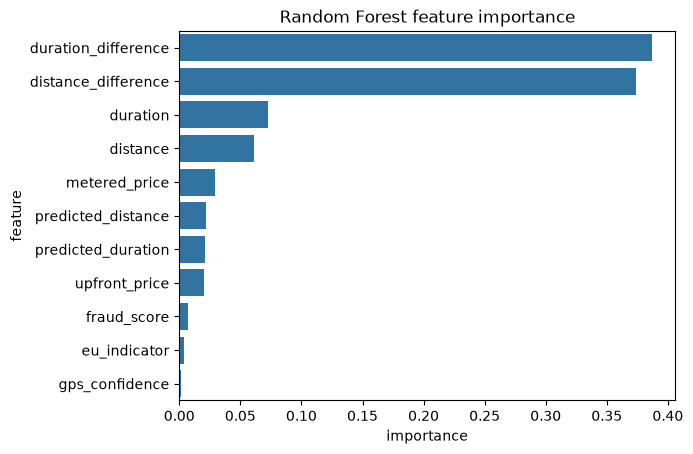

In [323]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature"
)

plt.title("Random Forest feature importance")
plt.show()

In [329]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loome duration_difference väärtuste vahemiku
duration_values = np.linspace(
    X["duration_difference"].quantile(0.01),
    X["duration_difference"].quantile(0.99),
    100
)

# Võtame ülejäänud tunnustele tüüpilised väärtused
X_visual = pd.DataFrame({
    "metered_price": X["metered_price"].median(),
    "upfront_price": X["upfront_price"].median(),
    "distance": X["distance"].median(),
    "duration": X["duration"].median(),
    "gps_confidence": X["gps_confidence"].mode()[0],
    "predicted_distance": X["predicted_distance"].median(),
    "predicted_duration": X["predicted_duration"].median(),
    "duration_difference": duration_values,
    "distance_difference": X["distance_difference"].median(),
    "eu_indicator": X["eu_indicator"].mode()[0],
    "fraud_score": X["fraud_score"].median()
})

# Mudeli hinnang OVERCHARGE klassi tõenäosusele
X_visual["overcharge_probability"] = rf.predict_proba(
    X_visual[X.columns]
)[:, list(rf.classes_).index("OVERCHARGE")]

X_visual.head()

,metered_price,upfront_price,distance,duration,gps_confidence,predicted_distance,predicted_duration,duration_difference,distance_difference,eu_indicator,fraud_score,overcharge_probability
0,7.37,6.6,6549.0,895.0,1,6365.0,839.0,-1699.000000,171.0,1,-280.0,0.13634
1,7.37,6.6,6549.0,895.0,1,6365.0,839.0,-1638.320808,171.0,1,-280.0,0.13634
2,7.37,6.6,6549.0,895.0,1,6365.0,839.0,-1577.641616,171.0,1,-280.0,0.13634
3,7.37,6.6,6549.0,895.0,1,6365.0,839.0,-1516.962424,171.0,1,-280.0,0.13634
4,7.37,6.6,6549.0,895.0,1,6365.0,839.0,-1456.283232,171.0,1,-280.0,0.13634


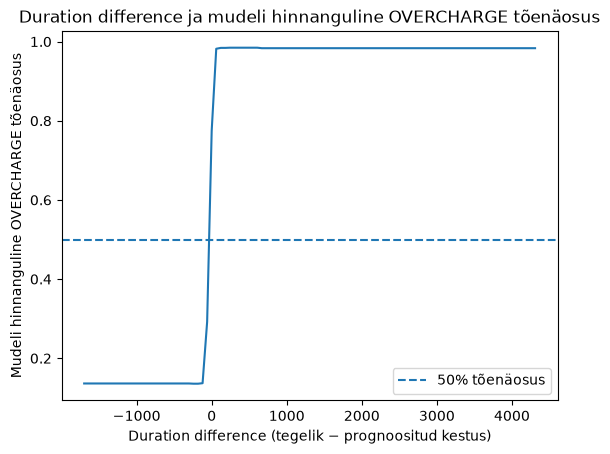

In [330]:
sns.lineplot(
    data=X_visual,
    x="duration_difference",
    y="overcharge_probability"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="50% tõenäosus"
)

plt.xlabel("Duration difference (tegelik − prognoositud kestus)")
plt.ylabel("Mudeli hinnanguline OVERCHARGE tõenäosus")
plt.title("Duration difference ja mudeli hinnanguline OVERCHARGE tõenäosus")
plt.legend()
plt.show()

## JÄRELDUS: Random Forest kasutas duration_difference tunnust oma klassifitseerimisotsustes kõige rohkem.